In [43]:
import cv2
import matplotlib.pylab as plt
import numpy as np

### **inisialisasi library** 

### deklarasi variabel untuk gambar yang diolah

Memuat gambar dari file assets dengan nama 'backup.png' menggunakan fungsi plt.imread(), yang mengonversi gambar menjadi array numerik. Fungsi cv2.cvtColor() digunakan untuk mengonversi gambar dari format warna BGR (Blue, Green, Red) ke grayscale menggunakan cv2.COLOR_BGR2GRAY. Gambar kemudian ditampilkan menggunakan plt.imshow(), yang memungkinkan gambar ditampilkan di jendela plot. print(sisitv.shape) menampilkan ukuran serta jumlah channel gambar

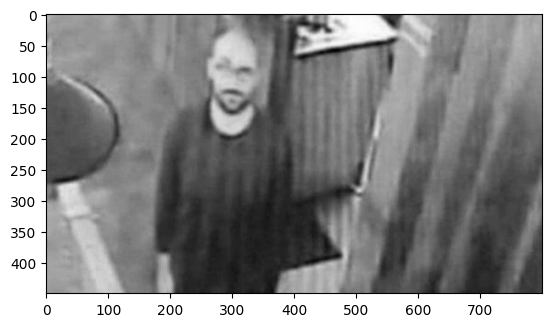

(450, 800)


In [44]:
cctv = plt.imread('Assets/backup.jpg')
sisitv = cv2.cvtColor (cctv, cv2.COLOR_BGR2GRAY)
plt.imshow(sisitv, cmap = 'gray')
plt.show()
print(sisitv.shape)

### filtering 

Fungsi filter(img, size, mode) digunakan untuk menerapkan filter spasial pada citra grayscale dengan tiga pilihan metode, yaitu mean, median, dan modus. Program terlebih dahulu menambahkan padding pada tepi citra agar proses filtering dapat dilakukan hingga bagian pinggir gambar. Setelah itu dibuat array canvas sebagai tempat penyimpanan hasil filter. Pada mode 'mean', nilai setiap piksel dihitung dari rata-rata area kernel sehingga citra menjadi lebih halus. Pada mode 'median', nilai piksel diganti dengan nilai tengah dari area kernel untuk mengurangi noise seperti salt and pepper. Sedangkan pada mode 'modus', nilai piksel diganti dengan nilai yang paling sering muncul di area kernel. Hasil filtering kemudian dikembalikan dalam bentuk citra baru melalui return canvas.

In [45]:
def filter(img, size, mode):
    # dimensi gambar / image dimensions
    height, width = img.shape

    # ukuran padding / padding size
    pad = size // 2

    # tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode='edge')

    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:

        case 'mean':
            # filter rata-rata / mean filter
            area = size * size

            for i in range(height):
                for j in range(width):

                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size].astype(np.float32)

                    # rumus mean manual / manual mean formula
                    total = 0
                    for row in region:
                        for val in row:
                            total += val

                    mean_val = total // area

                    # simpan hasil / save result
                    canvas[i, j] = mean_val

        case 'median':
            # filter median / median filter
            for i in range(height):
                for j in range(width):

                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]

                    # rumus median manual / manual median formula
                    values = region.ravel().tolist()
                    values.sort()

                    mid = len(values) // 2
                    median_val = values[mid]

                    # simpan hasil / save result
                    canvas[i, j] = median_val

        case 'modus':
            # filter modus / mode filter
            for i in range(height):
                for j in range(width):

                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]

                    # ratakan array / flatten array
                    values = region.ravel()

                    # hitung kemunculan / count occurrences
                    count = {}

                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1

                    # cari nilai terbanyak / find mode value
                    max_count = 0
                    mode_val = 0

                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val

                    # simpan hasil / save result
                    canvas[i, j] = mode_val

    # kembalikan gambar / return image
    return canvas


# cara panggil / how to call
# hasil = filter(foto_karim, 3, 'mean')

### konvolusi

Fungsi convolution(img, kernel) digunakan untuk melakukan proses konvolusi pada citra grayscale menggunakan kernel tertentu. Program terlebih dahulu menentukan ukuran kernel dan menambahkan zero padding pada tepi citra agar proses konvolusi dapat dilakukan hingga bagian pinggir gambar. Setelah itu dibuat array canvas sebagai tempat penyimpanan hasil konvolusi. Program kemudian melakukan perulangan pada setiap piksel citra, mengambil area sesuai ukuran kernel (region), lalu menghitung hasil konvolusi menggunakan np.sum(region * kernel). Nilai hasil tersebut disimpan ke dalam canvas sehingga menghasilkan citra baru sesuai efek kernel yang digunakan.

In [46]:
def convolution(img, kernel):

    # ukuran kernel / kernel size
    size = kernel.shape[0]

    # ukuran padding / padding size
    pad_size = size // 2

    # tambah padding nol / add zero padding
    padded = np.pad(img, pad_size, mode='constant')

    # kanvas hasil / output canvas
    canvas = np.zeros_like(img).astype(np.float32)

    # dimensi gambar / image dimensions
    height, width = img.shape

    # loop baris / loop rows
    for i in range(height):

        # loop kolom / loop columns
        for j in range(width):

            # area kernel / kernel region
            region = padded[i:i+size, j:j+size]

            # hitung konvolusi / compute convolution
            canvas[i, j] = np.sum(region * kernel)

    # kembalikan gambar / return image
    return canvas


# cara panggil / how to call
# hasil = convolution(fotoMarsha, kernel)

In [47]:
# kernel penghalus gambar / image smoothing kernel
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10,  1/5, 1/10],
    [1/10, 1/10, 1/10]
])

# kernel penajam gambar / image sharpening kernel
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

### kernel konvolusi untuk smoothing dan sharpening

### panggil fungsi filtering, smooth dan sharp

menerapkan beberapa teknik filtering pada citra sisitv. Fungsi filter() digunakan untuk menghasilkan filter mean, median, dan modus dengan ukuran kernel 3×3 dan 9×9. Filter mean digunakan untuk menghaluskan citra dengan menghitung rata-rata piksel, filter median digunakan untuk mengurangi noise dengan mengambil nilai tengah, sedangkan filter modus menggunakan nilai yang paling sering muncul pada area kernel. Selain itu, fungsi convolution() digunakan dengan kernelSmoothing untuk menghasilkan efek penghalusan citra dan kernelSharpening untuk mempertajam detail pada citra.

In [48]:
mean3x3 = filter(sisitv, 3, 'mean')
mean9x9 = filter(sisitv, 9, 'mean')
median3x3 = filter(sisitv, 3, 'median')
median9x9 = filter(sisitv, 9, 'median')
modus3x3 = filter(sisitv, 3, 'modus')
modus9x9 = filter(sisitv, 9, 'modus')

# smoothing
smoothing = convolution(sisitv, kernelSmoothing)

# sharpening
sharpening = convolution(sisitv, kernelSharpening)

### menampilkan

menampilkan hasil berbagai proses filtering dan konvolusi pada citra sisitv dalam susunan subplot 3×3. Gambar asli, hasil filter mean, median, modus, smoothing, dan sharpening ditampilkan menggunakan plt.imshow() dengan colormap grayscale. Setiap subplot diberi judul menggunakan plt.title() agar mudah dibedakan, sedangkan plt.axis('off') digunakan untuk menyembunyikan sumbu gambar. Fungsi plt.tight_layout() digunakan agar jarak antar subplot menjadi lebih rapi sebelum seluruh hasil ditampilkan dengan plt.show().

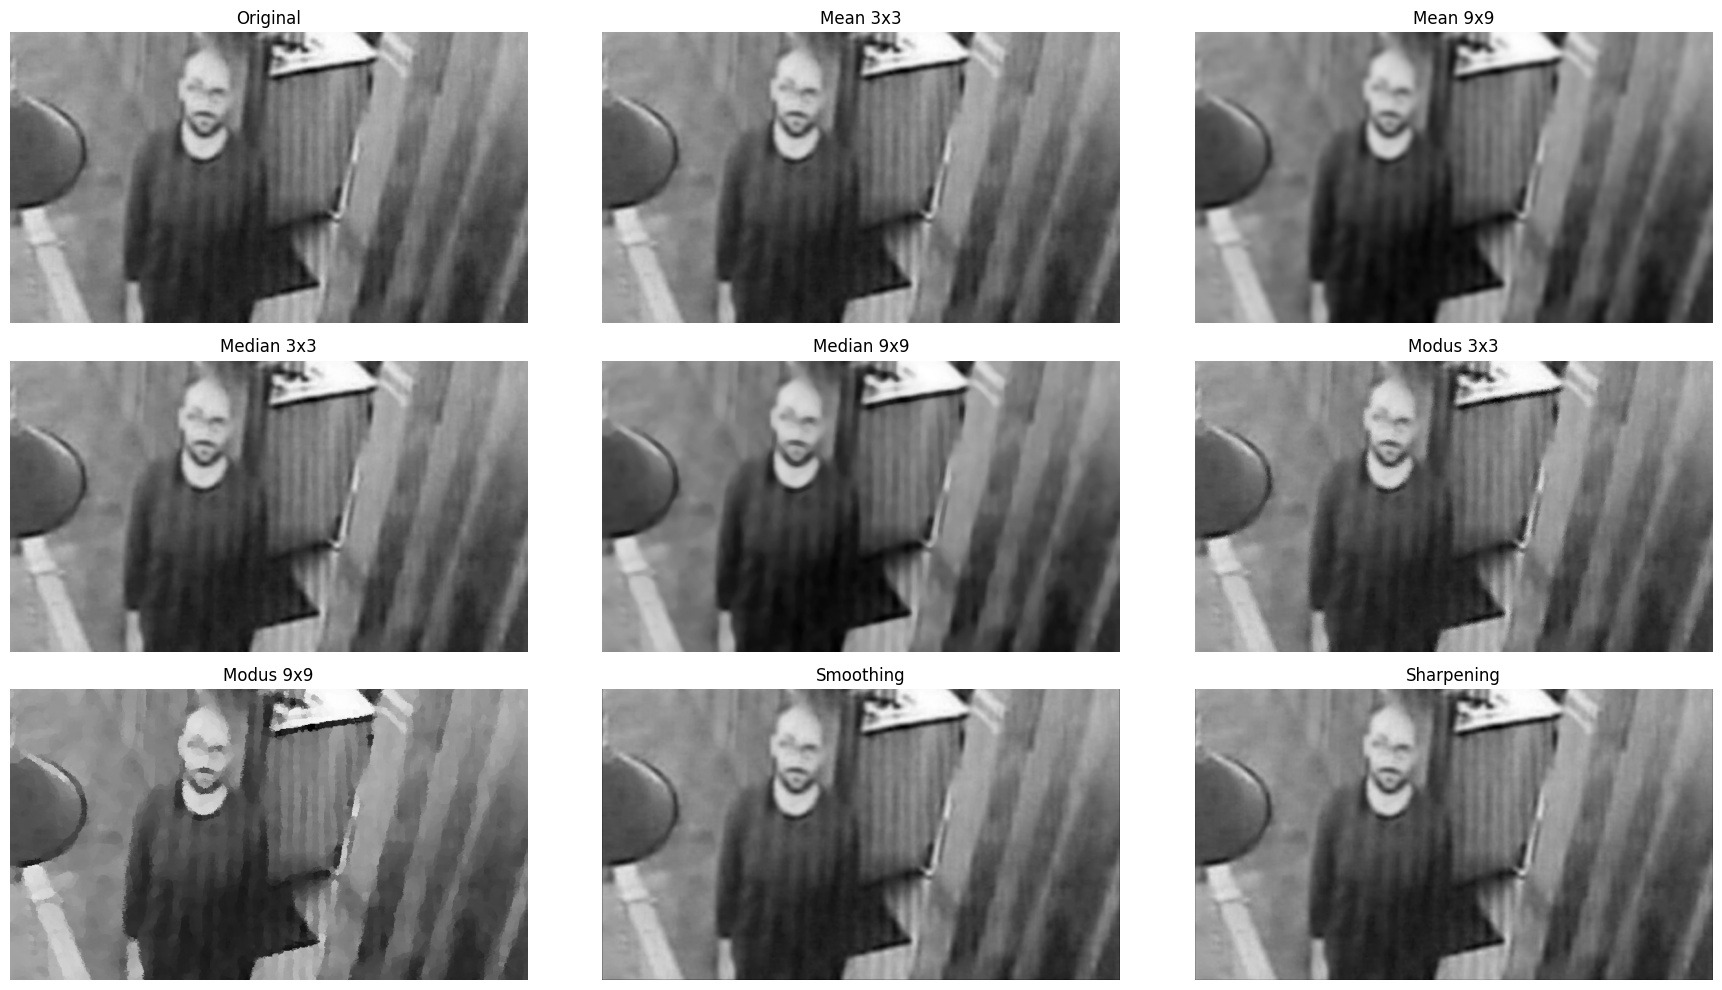

In [49]:
# tampilkan hasil
plt.figure(figsize=(18,10))

plt.subplot(3,3,1)
plt.imshow(sisitv, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(3,3,2)
plt.imshow(mean3x3, cmap='gray')
plt.title('Mean 3x3')
plt.axis('off')

plt.subplot(3,3,3)
plt.imshow(mean9x9, cmap='gray')
plt.title('Mean 9x9')
plt.axis('off')

plt.subplot(3,3,4)
plt.imshow(median3x3, cmap='gray')
plt.title('Median 3x3')
plt.axis('off')

plt.subplot(3,3,5)
plt.imshow(median9x9, cmap='gray')
plt.title('Median 9x9')
plt.axis('off')

plt.subplot(3,3,6)
plt.imshow(modus3x3, cmap='gray')
plt.title('Modus 3x3')
plt.axis('off')

plt.subplot(3,3,7)
plt.imshow(modus9x9, cmap='gray')
plt.title('Modus 9x9')
plt.axis('off')

plt.subplot(3,3,8)
plt.imshow(smoothing, cmap='gray')
plt.title('Smoothing')
plt.axis('off')

plt.subplot(3,3,9)
plt.imshow(sharpening, cmap='gray')
plt.title('Sharpening')
plt.axis('off')

plt.tight_layout()
plt.show()

### perbedaan mean, median, modus

Perbedaan utama antara metode Mean, Median, dan Modus terletak pada cara menentukan nilai piksel baru pada area kernel. Filter Mean menghitung rata-rata seluruh nilai piksel di sekitar sehingga menghasilkan citra yang lebih halus, namun detail gambar dapat menjadi blur. Filter Median mengambil nilai tengah dari kumpulan piksel pada kernel sehingga lebih efektif untuk menghilangkan noise salt and pepper tanpa terlalu merusak tepi objek. Sedangkan filter Modus memilih nilai piksel yang paling sering muncul pada area kernel sehingga dapat mempertahankan pola atau area dengan intensitas dominan.

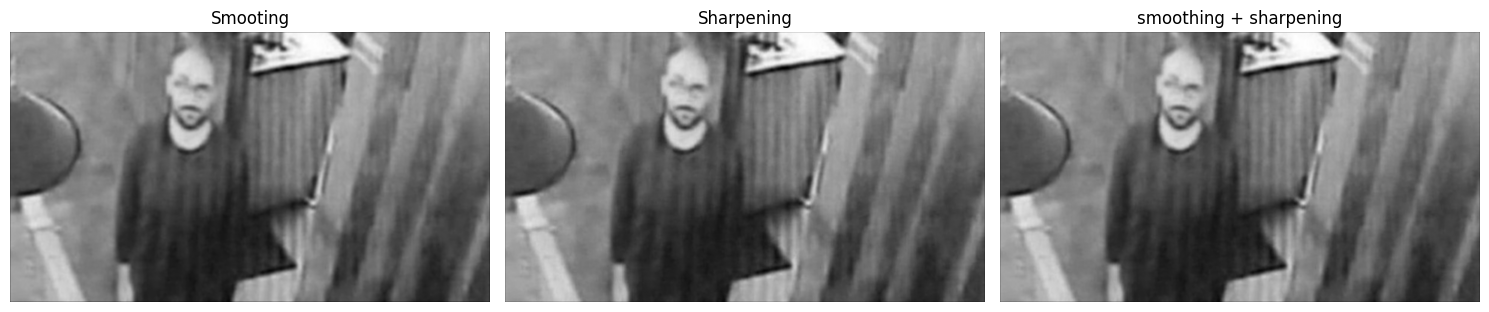

In [50]:
hasil = smoothing + sharpening

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.title("Smooting")
plt.imshow(smoothing, cmap="gray")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Sharpening")
plt.imshow(sharpening, cmap="gray")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hasil, cmap = 'gray')
plt.title("smoothing + sharpening")
plt.axis('off')

plt.tight_layout()
plt.show()

### perbedaan 

Pada bagian ini terlihat perbedaan dari ketiga metode yang digunakan. Metode smoothing menghasilkan citra yang lebih halus, namun beberapa detail pada gambar menjadi kurang terlihat. Metode sharpening menghasilkan gambar yang lebih tajam dan detail objek tampak lebih jelas. Sementara itu, metode gabungan dari kedua operator menghasilkan citra yang tetap halus tetapi masih memiliki tingkat ketajaman yang cukup baik, meskipun detailnya tidak setajam hasil metode sharpening.

In [51]:
# kernel sobel sumbu x / x-axis sobel kernel
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# kernel sobel sumbu y / y-axis sobel kernel
sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)


# kernel prewitt sumbu x / x-axis prewitt kernel
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

# kernel prewitt sumbu y / y-axis prewitt kernel
prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)


# kernel roberts sumbu x / x-axis roberts kernel
robertsX = np.array([
    [ 1,  0],
    [ 0, -1]
], dtype=np.float32)

# kernel roberts sumbu y / y-axis roberts kernel
robertsY = np.array([
    [ 0,  1],
    [-1,  0]
], dtype=np.float32)

### kernel deteksi tepi untuk metode prewitt, sobel, roberts

### fungsi edge

Fungsi edge(img, kernelx, kernely) digunakan untuk melakukan deteksi tepi pada citra menggunakan kernel pada sumbu x dan y yang ada di kode sebelumnya. Program terlebih dahulu melakukan konvolusi citra dengan kernelx untuk mendapatkan gradien horizontal (gx) dan dengan kernely untuk mendapatkan gradien vertikal (gy). Setelah itu, kedua gradien digabung menggunakan nilai absolut sehingga menghasilkan citra tepi yang lebih jelas. Hasil kemudian dinormalisasi ke rentang 0–255 agar intensitas piksel sesuai format citra, lalu dikonversi menjadi uint8. Fungsi ini dapat digunakan dengan berbagai metode deteksi tepi seperti Sobel, Prewitt, dan Roberts tergantung kernel yang diberikan.

In [52]:
def edge(img, kernelx, kernely):

    # konvolusi sumbu x / x-axis convolution
    gx = convolution(img, kernelx)

    # konvolusi sumbu y / y-axis convolution
    gy = convolution(img, kernely)

    # kanvas kosong / empty canvas
    canvas = np.zeros_like(img, dtype=np.float32)

    # gabung gradient absolut / combine absolute gradients
    canvas = np.abs(gx) + np.abs(gy)

    # normalisasi ke 0-255 / normalize to 0-255
    canvas = canvas * 255.0 / np.max(canvas)

    # batas nilai dan konversi / clip values and convert
    return np.clip(canvas, 0, 255).astype(np.uint8)


# cara panggil / how to call
# hasil_tepi = edge(fotoTania, prewittX, prewittY)

### sobel

menerapkan deteksi tepi metode Sobel pada citra asli serta berbagai hasil filtering sebelumnya. Fungsi edge() digunakan dengan kernel sobelX dan sobelY untuk menghasilkan citra tepi dari gambar asli, hasil filter mean, median, modus, smoothing, dan sharpening. Setelah proses deteksi tepi selesai, seluruh hasil ditampilkan menggunakan subplot 3×3 agar perbedaan hasil Sobel pada setiap metode filtering dapat dibandingkan dengan mudah.

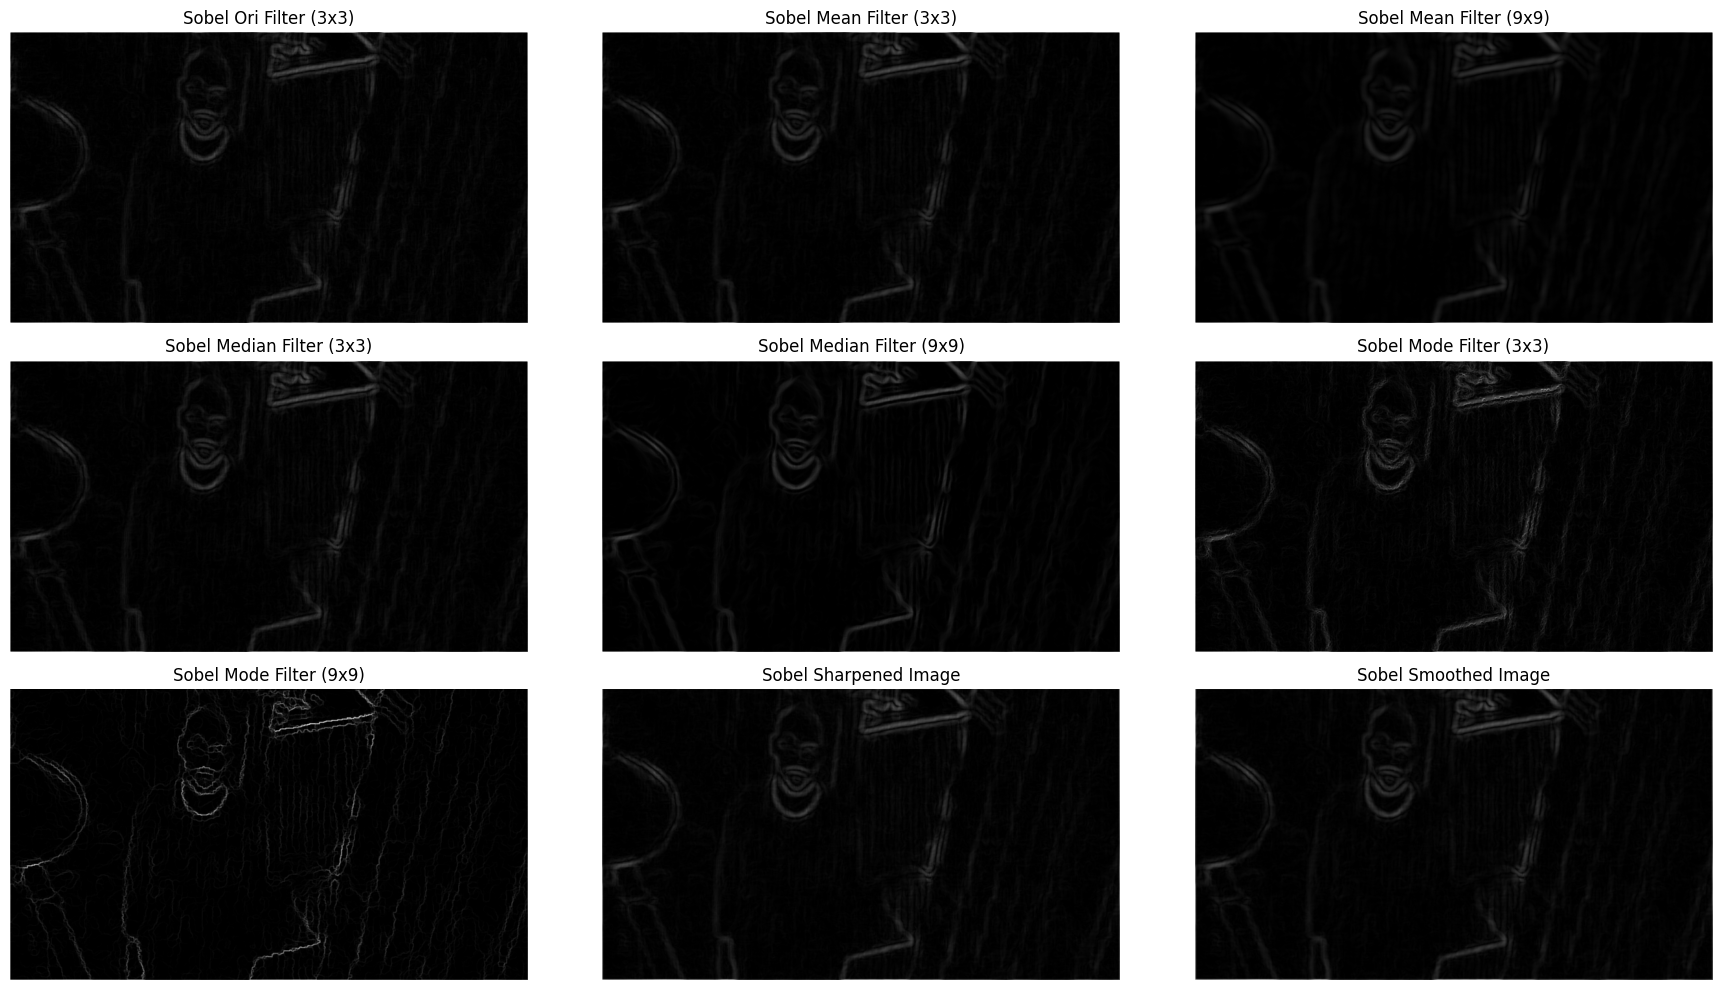

In [53]:
# SOBEL
sobelOri = edge(sisitv, sobelX, sobelY)

sobelMean3x3   = edge(mean3x3, sobelX, sobelY)
sobelMean9x9   = edge(mean9x9, sobelX, sobelY)

sobelMedian3x3 = edge(median3x3, sobelX, sobelY)
sobelMedian9x9 = edge(median9x9, sobelX, sobelY)

sobelModus3x3  = edge(modus3x3, sobelX, sobelY)
sobelModus9x9  = edge(modus9x9, sobelX, sobelY)

sobelSharp     = edge(sharpening, sobelX, sobelY)
sobelSmooth    = edge(smoothing, sobelX, sobelY)


plt.figure(figsize=(18,10))

plt.subplot(3,3,1)
plt.imshow(sobelOri, cmap='gray')
plt.title('Sobel Ori Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,2)
plt.imshow(sobelMean3x3, cmap='gray')
plt.title('Sobel Mean Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,3)
plt.imshow(sobelMean9x9, cmap='gray')
plt.title('Sobel Mean Filter (9x9)')
plt.axis('off')

plt.subplot(3,3,4)
plt.imshow(sobelMedian3x3, cmap='gray')
plt.title('Sobel Median Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,5)
plt.imshow(sobelMedian9x9, cmap='gray')
plt.title('Sobel Median Filter (9x9)')
plt.axis('off')

plt.subplot(3,3,6)
plt.imshow(sobelModus3x3, cmap='gray')
plt.title('Sobel Mode Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,7)
plt.imshow(sobelModus9x9, cmap='gray')
plt.title('Sobel Mode Filter (9x9)')
plt.axis('off')

plt.subplot(3,3,8)
plt.imshow(sobelSharp, cmap='gray')
plt.title('Sobel Sharpened Image')
plt.axis('off')

plt.subplot(3,3,9)
plt.imshow(sobelSmooth, cmap='gray')
plt.title('Sobel Smoothed Image')
plt.axis('off')

plt.tight_layout()
plt.show()

### prewitt

menerapkan deteksi tepi metode Prewitt pada citra asli dan berbagai hasil filtering seperti mean, median, modus, smoothing, dan sharpening. Fungsi edge() dipanggil menggunakan kernel prewittX dan prewittY untuk menghasilkan citra tepi berdasarkan perubahan intensitas pada sumbu x dan y. Seluruh hasil deteksi tepi kemudian ditampilkan dalam subplot 3×3 sehingga perbedaan hasil metode Prewitt pada setiap jenis filter dapat dibandingkan dengan lebih mudah.

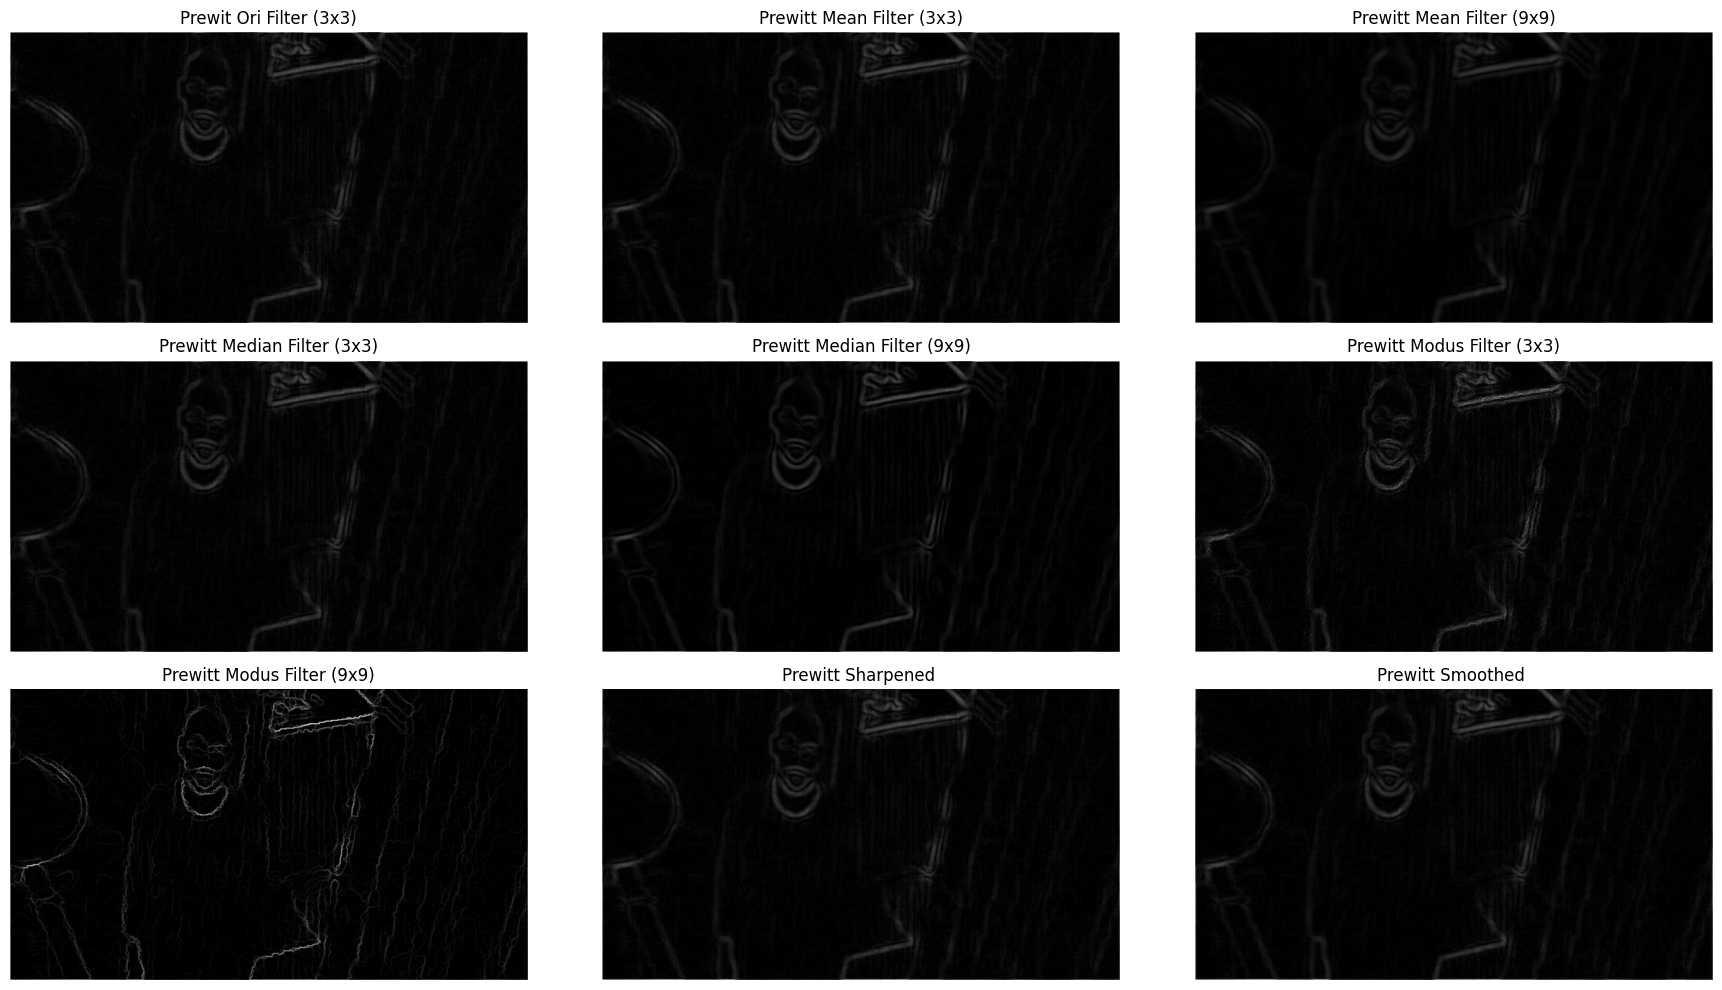

In [54]:
# PREWITT
prewittOri = edge(sisitv, prewittX, prewittY)

prewittMean3x3   = edge(mean3x3, prewittX, prewittY)
prewittMean9x9   = edge(mean9x9, prewittX, prewittY)

prewittMedian3x3 = edge(median3x3, prewittX, prewittY)
prewittMedian9x9 = edge(median9x9, prewittX, prewittY)

prewittModus3x3  = edge(modus3x3, prewittX, prewittY)
prewittModus9x9  = edge(modus9x9, prewittX, prewittY)

prewittSharp     = edge(sharpening, prewittX, prewittY)
prewittSmooth    = edge(smoothing, prewittX, prewittY)


plt.figure(figsize=(18,10))

plt.subplot(3,3,1)
plt.imshow(prewittOri, cmap='gray')
plt.title('Prewit Ori Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,2)
plt.imshow(prewittMean3x3, cmap='gray')
plt.title('Prewitt Mean Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,3)
plt.imshow(prewittMean9x9, cmap='gray')
plt.title('Prewitt Mean Filter (9x9)')
plt.axis('off')

plt.subplot(3,3,4)
plt.imshow(prewittMedian3x3, cmap='gray')
plt.title('Prewitt Median Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,5)
plt.imshow(prewittMedian9x9, cmap='gray')
plt.title('Prewitt Median Filter (9x9)')
plt.axis('off')

plt.subplot(3,3,6)
plt.imshow(prewittModus3x3, cmap='gray')
plt.title('Prewitt Modus Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,7)
plt.imshow(prewittModus9x9, cmap='gray')
plt.title('Prewitt Modus Filter (9x9)')
plt.axis('off')

plt.subplot(3,3,8)
plt.imshow(prewittSharp, cmap='gray')
plt.title('Prewitt Sharpened ')
plt.axis('off')

plt.subplot(3,3,9)
plt.imshow(prewittSmooth, cmap='gray')
plt.title('Prewitt Smoothed ')
plt.axis('off')

plt.tight_layout()
plt.show()

### roberts

menerapkan deteksi tepi metode Roberts pada citra asli dan hasil berbagai proses filtering seperti mean, median, modus, smoothing, dan sharpening. Fungsi edge() dijalankan menggunakan kernel robertsX dan robertsY untuk mendeteksi perubahan intensitas piksel pada arah horizontal dan vertikal. Hasil deteksi tepi dari setiap citra kemudian ditampilkan dalam susunan subplot 3×3 sehingga perbedaan efek metode Roberts pada masing-masing filter dapat diamati dengan mudah.

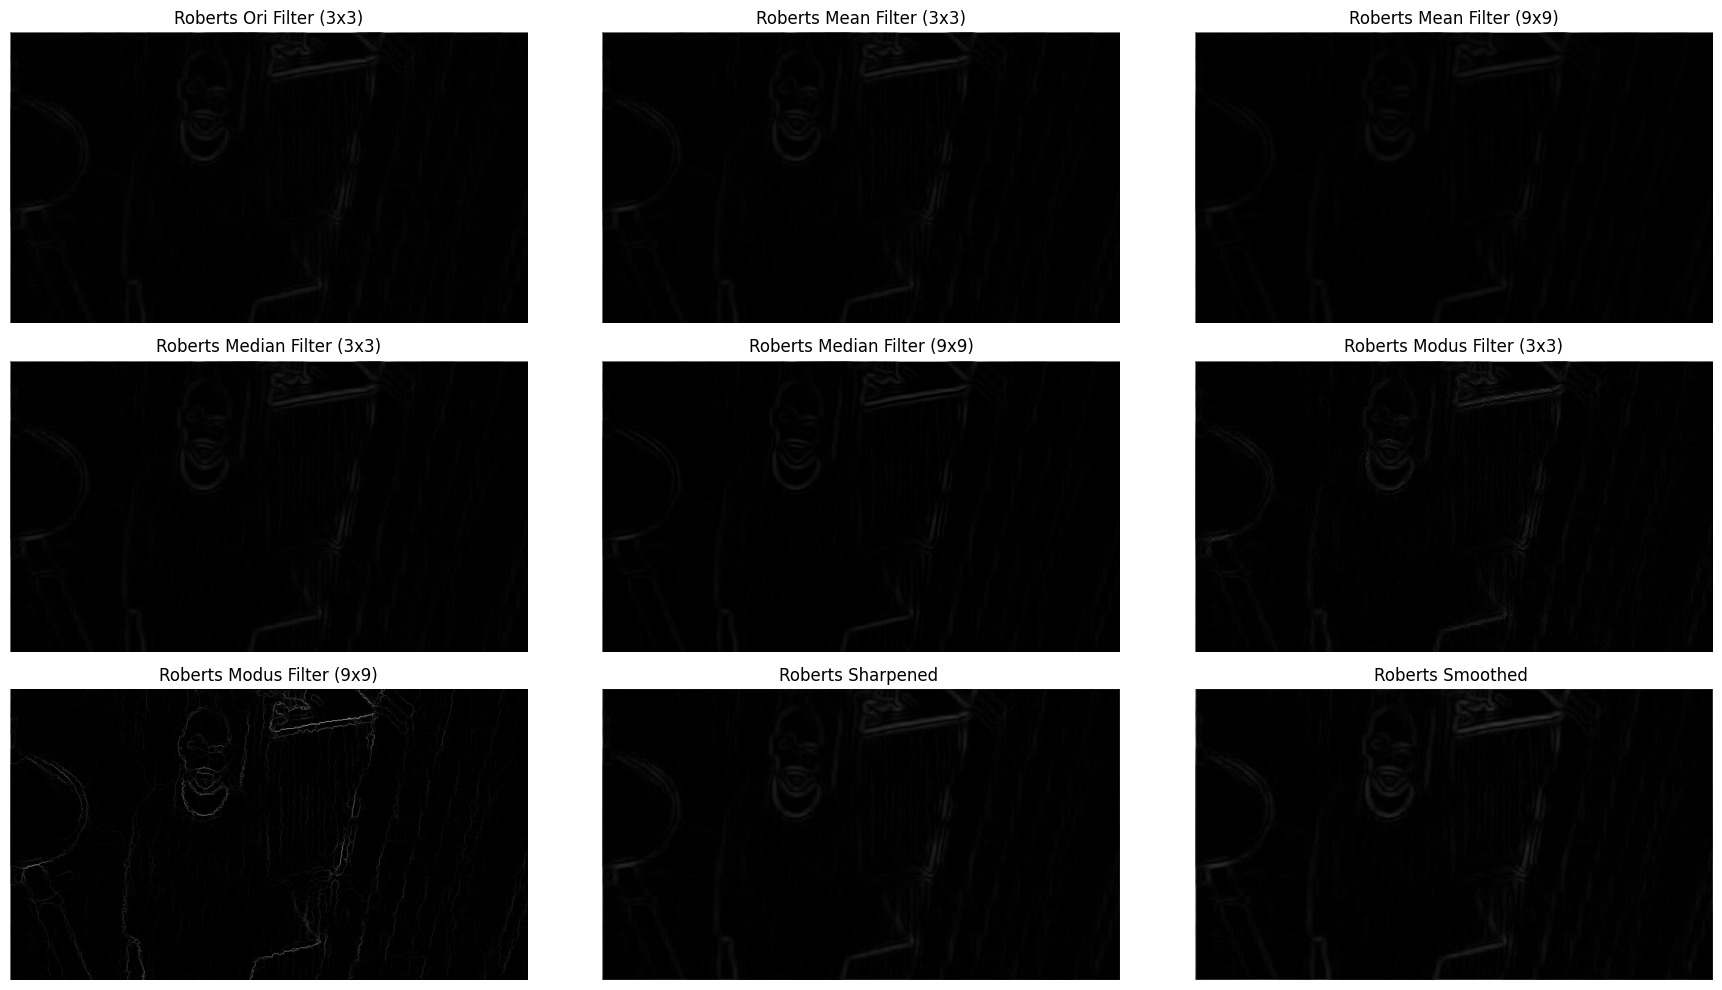

In [55]:
# ROBERTS
robertsOri = edge(sisitv, robertsX, robertsY)

robertsMean3x3   = edge(mean3x3, robertsX, robertsY)
robertsMean9x9   = edge(mean9x9, robertsX, robertsY)

robertsMedian3x3 = edge(median3x3, robertsX, robertsY)
robertsMedian9x9 = edge(median9x9, robertsX, robertsY)

robertsModus3x3  = edge(modus3x3, robertsX, robertsY)
robertsModus9x9  = edge(modus9x9, robertsX, robertsY)

robertsSharp     = edge(sharpening, robertsX, robertsY)
robertsSmooth    = edge(smoothing, robertsX, robertsY)


plt.figure(figsize=(18,10))

plt.subplot(3,3,1)
plt.imshow(robertsOri, cmap='gray')
plt.title('Roberts Ori Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,2)
plt.imshow(robertsMean3x3, cmap='gray')
plt.title('Roberts Mean Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,3)
plt.imshow(robertsMean9x9, cmap='gray')
plt.title('Roberts Mean Filter (9x9)')
plt.axis('off')

plt.subplot(3,3,4)
plt.imshow(robertsMedian3x3, cmap='gray')
plt.title('Roberts Median Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,5)
plt.imshow(robertsMedian9x9, cmap='gray')
plt.title('Roberts Median Filter (9x9)')
plt.axis('off')

plt.subplot(3,3,6)
plt.imshow(robertsModus3x3, cmap='gray')
plt.title('Roberts Modus Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,7)
plt.imshow(robertsModus9x9, cmap='gray')
plt.title('Roberts Modus Filter (9x9)')
plt.axis('off')

plt.subplot(3,3,8)
plt.imshow(robertsSharp, cmap='gray')
plt.title('Roberts Sharpened ')
plt.axis('off')

plt.subplot(3,3,9)
plt.imshow(robertsSmooth, cmap='gray')
plt.title('Roberts Smoothed ')
plt.axis('off')

plt.tight_layout()
plt.show()

### gabungan operator

menggabungkan hasil deteksi tepi dari metode Prewitt, Sobel, dan Roberts pada citra asli. Variabel presol, prerob, dan sorob merupakan hasil penjumlahan dua metode deteksi tepi, sedangkan presorob merupakan gabungan dari ketiga metode sekaligus. Setelah itu, seluruh hasil ditampilkan menggunakan subplot sehingga perbedaan hasil masing-masing metode maupun hasil kombinasi antar metode dapat dibandingkan dengan mudah.

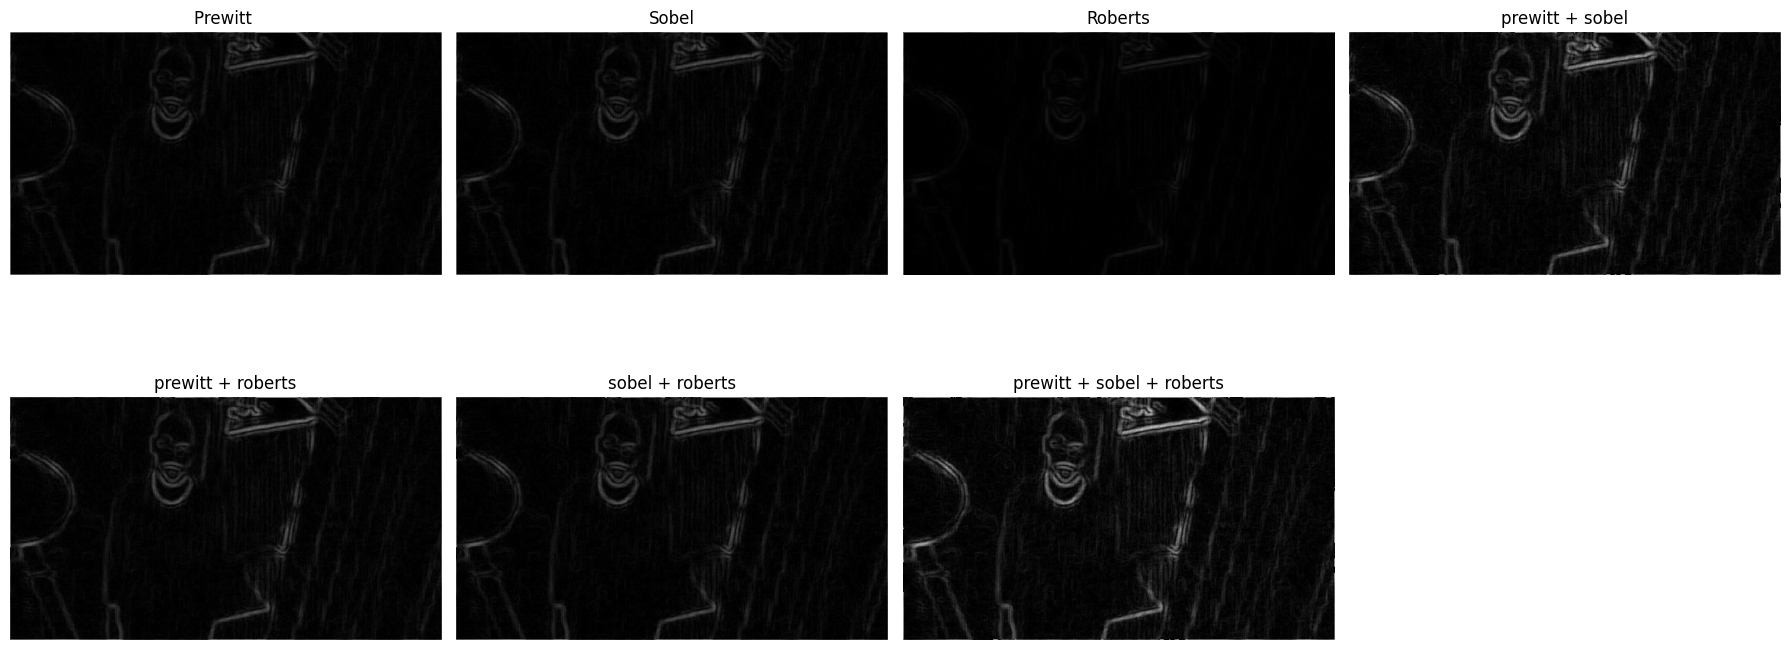

In [56]:
# ukuran 3x3

presol = prewittOri + sobelOri
prerob = prewittOri + robertsOri
sorob = sobelOri + robertsOri
presorob = presol + robertsOri

plt.figure(figsize=(18,8))

plt.subplot(2,4,1)
plt.imshow(prewittOri, cmap = 'gray')
plt.title('Prewitt ')
plt.axis('off')

plt.subplot(2,4,2)
plt.imshow(sobelOri, cmap = 'gray')
plt.title('Sobel')
plt.axis('off')

plt.subplot(2,4,3)
plt.imshow(robertsOri, cmap = 'gray')
plt.title('Roberts')
plt.axis('off')

plt.subplot(2,4,4)
plt.imshow(presol, cmap = 'gray')
plt.title('prewitt + sobel')
plt.axis('off')

plt.subplot(2,4,5)
plt.imshow(prerob, cmap = 'gray')
plt.title('prewitt + roberts')
plt.axis('off')

plt.subplot(2,4,6)
plt.imshow(sorob, cmap = 'gray')
plt.title('sobel + roberts')
plt.axis('off')

plt.subplot(2,4,7)
plt.imshow(presorob, cmap = 'gray')
plt.title('prewitt + sobel + roberts')
plt.axis('off')

plt.tight_layout()
plt.show()


### kegunaan operator

digunakan operator Prewitt, Sobel, Roberts, serta kombinasi dari beberapa operator. Masing-masing operator memiliki karakteristik yang berbeda, namun secara umum semuanya digunakan untuk mendeteksi tepi pada citra. Oleh karena itu, setiap operator menghasilkan bentuk deteksi tepi yang berbeda-beda. Berdasarkan hasil analisis, operator Roberts menghasilkan deteksi tepi yang paling tipis dibandingkan operator lainnya. Sementara itu, hasil yang paling jelas terlihat diperoleh dari kombinasi operator Prewitt, Sobel, dan Roberts karena mampu menampilkan tepi objek dengan lebih kuat dan detail.

### thresholding

Fungsi thresholding(img, threshold) digunakan untuk mengubah citra grayscale menjadi citra biner berdasarkan nilai threshold tertentu. Program memeriksa setiap piksel pada gambar, kemudian membandingkannya dengan nilai threshold. Jika nilai piksel lebih besar dari threshold, maka piksel diubah menjadi putih (255), sedangkan jika lebih kecil atau sama maka diubah menjadi hitam (0). Hasil akhirnya berupa citra biner yang memisahkan objek dan latar belakang berdasarkan intensitas piksel.

In [57]:
def thresholding(img, threshold):

    # dimensi gambar / image dimensions
    height, width = img.shape

    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)

    # proses thresholding
    for i in range(height):
        for j in range(width):

            # jika lebih besar dari threshold
            if img[i, j] > threshold:
                canvas[i, j] = 255

            # jika lebih kecil atau sama
            else:
                canvas[i, j] = 0

    # kembalikan hasil
    return canvas


# cara panggil / how to call
# hasil = thresholding(superr, 128)

### penerapan thresholding

digunakan untuk menerapkan thresholding pada hasil deteksi tepi Sobel (sobelOri) dengan beberapa nilai threshold yang berbeda, yaitu 10 hingga 60. Setiap nilai threshold menghasilkan citra biner yang berbeda karena menentukan batas intensitas piksel yang akan diubah menjadi putih atau hitam. Semakin besar nilai threshold, semakin sedikit detail tepi yang terlihat karena hanya piksel dengan intensitas tinggi yang dipertahankan. Seluruh hasil kemudian ditampilkan menggunakan subplot agar perbedaan hasil thresholding dapat dibandingkan dengan mudah.

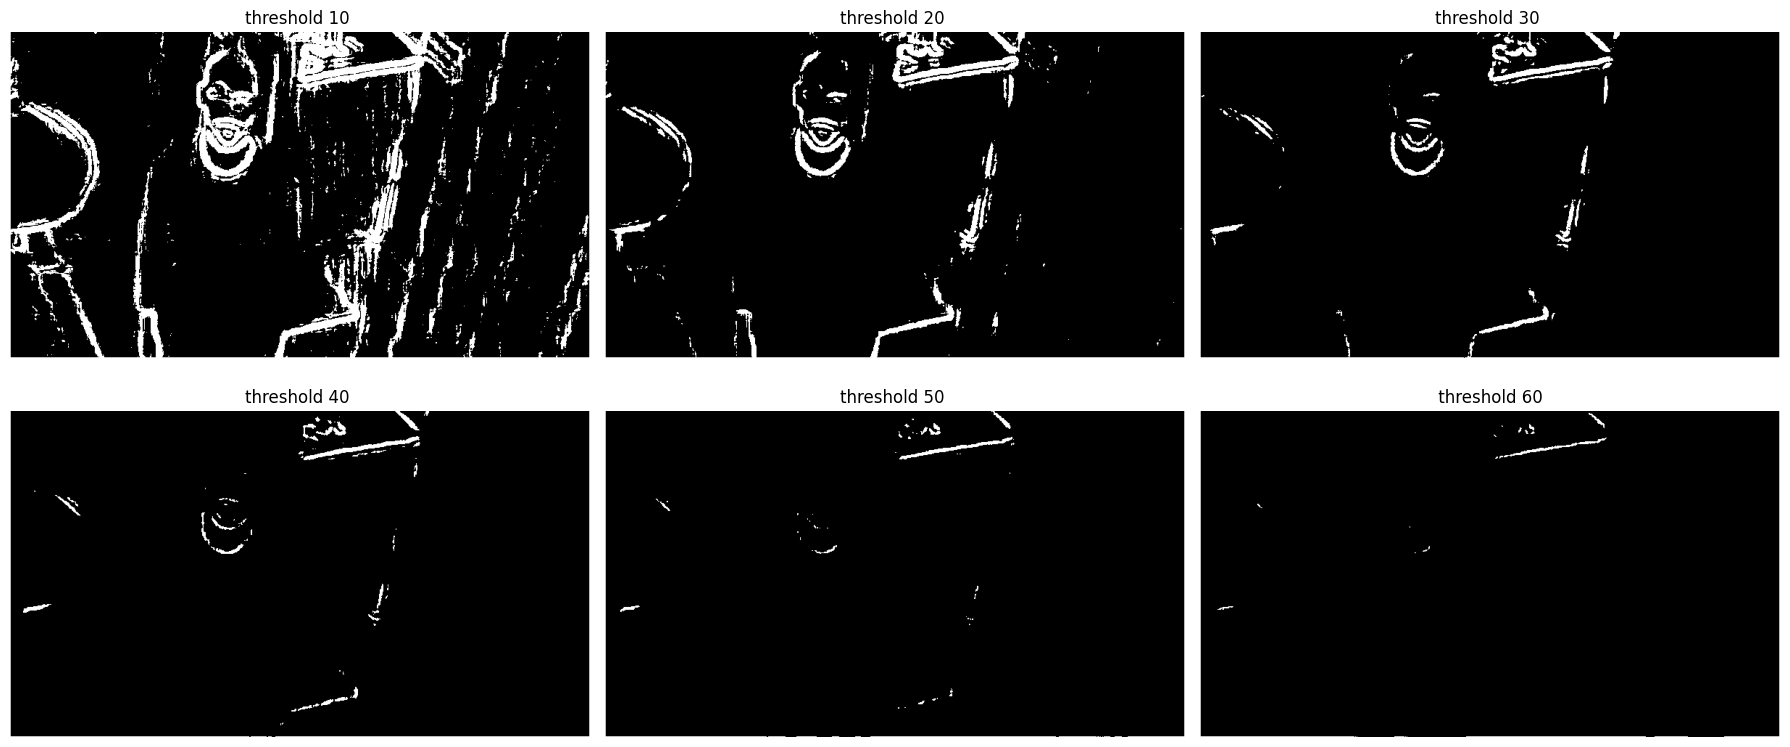

In [58]:
thresh1 = thresholding(sobelOri, 10)
thresh2 = thresholding(sobelOri, 20)
thresh3 = thresholding(sobelOri, 30)
thresh4 = thresholding(sobelOri, 40)
thresh5 = thresholding(sobelOri, 50)
thresh6 = thresholding(sobelOri, 60)

plt.figure(figsize=(18,8))

plt.subplot(2,3,1)
plt.imshow(thresh1, cmap = 'gray')
plt.title('threshold 10 ')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(thresh2, cmap = 'gray')
plt.title('threshold 20 ')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(thresh3, cmap = 'gray')
plt.title('threshold 30 ')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(thresh4, cmap = 'gray')
plt.title('threshold 40 ')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(thresh5, cmap = 'gray')
plt.title('threshold 50 ')
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(thresh6, cmap ='gray')
plt.title(' threshold 60 ')
plt.axis('off')

plt.tight_layout()
plt.show()

### pengaruh dan yang terbagus

Pengaruh threshold terhadap hasil deteksi tepi adalah menentukan tingkat kejelasan garis tepi pada objek. Jika nilai threshold rendah, maka lebih banyak garis tepi yang muncul sehingga tepi objek terlihat lebih jelas dan tebal. Sebaliknya, jika nilai threshold semakin tinggi, maka hanya sedikit tepi yang terdeteksi sehingga detail garis menjadi kurang terlihat. Pada kasus ini, threshold 10 memberikan hasil terbaik karena garis tepi objek masih terlihat jelas sehingga bentuk orang pada gambar dapat dideteksi dengan lebih baik.

### highlight

membuat mask siluet tubuh pada citra berdasarkan titik koordinat polygon yang telah ditentukan. Fungsi fill_poly() mengisi area di dalam polygon sehingga menghasilkan mask putih pada area objek dan hitam pada latar belakang. Setelah itu, dilakukan deteksi tepi pada mask menggunakan operator Sobel melalui fungsi edge(), kemudian hasil tepi diperjelas dengan thresholding manual. Selanjutnya, citra asli sisitv dikonversi dari BGR ke RGB lalu area objek pada mask diberi highlight warna kuning menggunakan proses blending. Garis outline hasil deteksi tepi juga diberi warna kuning sehingga bentuk objek terlihat lebih jelas. Terakhir, program menampilkan hasil mask siluet, outline, dan citra highlight menggunakan subplot.

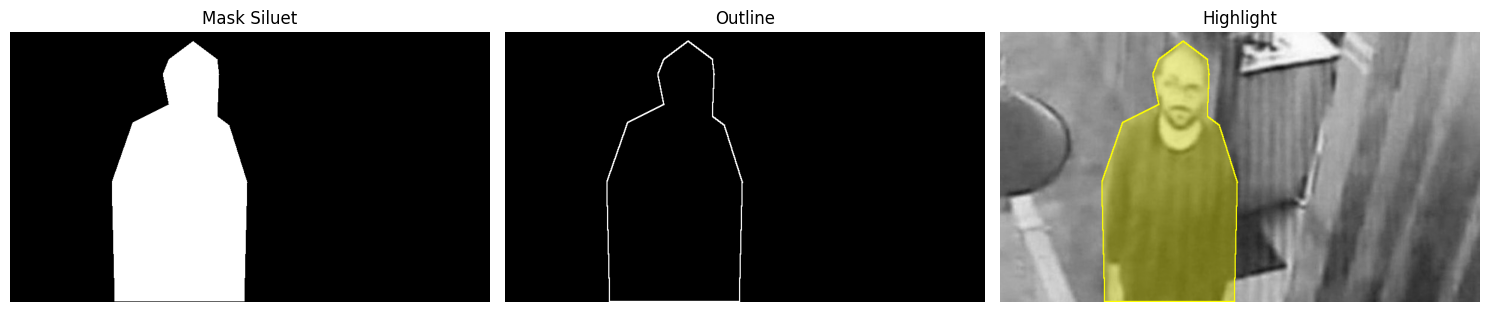

In [61]:
mask = np.zeros_like(sisitv, dtype=np.uint8)

points = np.array([
   [345, 45],   # Sisi kanan kepala
    [348, 70],  # Telinga kanan
    [345, 140],  # leher kanan
    [365, 155],  # Bahu kanan
    [395, 250],  # Lengan kanan luar
    [390, 449],  # Badan bawah kanan
    [175, 449],  # Badan bawah kiri
    [170, 250],  # Lengan kiri luar
    [205, 150],  # Bahu kiri
    [265, 120],  # Leher kiri
    [255, 70],  # Telinga kiri
    [265, 45],  # Sisi kiri Kepala
    [305, 15],   # Puncak kepala
    
], dtype=np.int32)
def fill_poly(mask, points):
    h = mask.shape[0]
    w = mask.shape[1]
    n = points.shape[0]

    for y in range(h):
        intersections = np.zeros(n, dtype=np.int32)
        count = 0

        for i in range(n):
            x1 = points[i, 0]
            y1 = points[i, 1]
            x2 = points[(i + 1) % n, 0]
            y2 = points[(i + 1) % n, 1]

            if (y1 <= y < y2) or (y2 <= y < y1):
                x_intersect = int(x1 + (y - y1) * (x2 - x1) / (y2 - y1))
                intersections[count] = x_intersect
                count += 1

        for a in range(count):
            for b in range(count - a - 1):
                if intersections[b] > intersections[b + 1]:
                    temp = intersections[b]
                    intersections[b] = intersections[b + 1]
                    intersections[b + 1] = temp

        for i in range(0, count - 1, 2):
            x_start = intersections[i]
            x_end   = intersections[i + 1]
            for x in range(x_start, x_end + 1):
                if 0 <= x < w:
                    mask[y, x] = 255

    return mask

mask = np.zeros_like(sisitv, dtype=np.uint8)
mask = fill_poly(mask, points)

# outline dari mask pakai detect_edge
outline = edge(mask, sobelX, sobelY)

# threshold manual
outline_thresh = np.zeros_like(outline, dtype=np.uint8)
for baris in range(outline.shape[0]):
    for kolom in range(outline.shape[1]):
        if outline[baris, kolom] > 30:
            outline_thresh[baris, kolom] = 255
        else:
            outline_thresh[baris, kolom] = 0

# highlight pakai gambar orang (BGR → RGB dulu)
highlight = cv2.cvtColor(sisitv, cv2.COLOR_BGR2RGB).copy()

highlight[mask == 255] = (
    0.65 * highlight[mask == 255] +
    0.35 * np.array([255, 255, 0])
).astype(np.uint8)

highlight[outline_thresh == 255] = [255, 255, 0]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Mask Siluet")
plt.imshow(mask, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Outline")
plt.imshow(outline_thresh, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Highlight")
plt.imshow(highlight)
plt.axis("off")

plt.tight_layout()
plt.show()

### david

membaca gambar david.jpg dan mengubahnya menjadi citra grayscale. Gambar dibaca menggunakan plt.imread() lalu dikonversi ke grayscale dengan fungsi cv2.cvtColor() menggunakan parameter cv2.COLOR_BGR2GRAY, dan hasilnya disimpan pada variabel davidd. Setelah itu, gambar ditampilkan menggunakan plt.imshow().

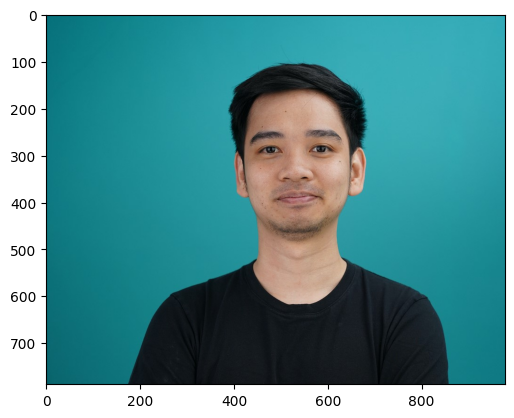

In [ ]:
david = plt.imread('Assets/david.jpg')
davidd = cv2.cvtColor (david, cv2.COLOR_BGR2GRAY)
plt.imshow(david, cmap = 'gray')

### deteksi tepi dan hapus bg

mendeteksi dan menghapus background berwarna toska pada gambar david. Fungsi detect_teal_background() mendeteksi area background dengan membandingkan nilai channel RGB, di mana warna toska memiliki dominasi channel hijau dan biru dibanding merah. Hasil deteksi berupa mask kemudian dikonversi menjadi citra biner dan diperhalus menggunakan filter median agar noise berkurang. Setelah itu, fungsi remove_background() digunakan untuk mengubah area background menjadi putih sehingga objek utama terpisah dari latar belakang. Selain itu, citra grayscale davidd juga diproses menggunakan kernel sharpening untuk mempertajam gambar, kemudian dilakukan deteksi tepi menggunakan operator Sobel sehingga menghasilkan citra tepi pada variabel davidtepi.

In [ ]:
def detect_teal_background(image_rgb):

    # ambil channel RGB
    R = image_rgb[:, :, 0].astype(int)
    G = image_rgb[:, :, 1].astype(int)
    B = image_rgb[:, :, 2].astype(int)

    # deteksi background warna toska
    mask_teal = (G > R + 15) & (B > R + 15)

    return mask_teal

def remove_background(image_rgb, mask_background):

    # salin gambar asli
    result = image_rgb.copy()

    # ubah background menjadi putih
    result[mask_background] = [255, 255, 255]

    return result

# deteksi background toska
mask_bg = detect_teal_background(david)

# ubah boolean ke uint8
mask_img = mask_bg.astype(np.uint8) * 255

# haluskan mask
mask_filtered = filter(mask_img, 5, 'median')

# background final
mask_bg_clean = mask_filtered > 127

# foreground final
mask_fg = ~mask_bg_clean

# hapus background
david_no_bg = remove_background(david, mask_bg_clean)

#sharpening david
davidsharp = convolution(davidd, kernelSharpening)

#tepi david
davidtepi = edge(davidsharp, sobelX, sobelY)

### hasil david

menampilkan tahapan hasil proses pengolahan citra pada gambar david dalam susunan subplot 1×4. Subplot pertama menampilkan citra asli, subplot kedua menampilkan hasil deteksi tepi menggunakan operator Sobel, subplot ketiga menampilkan mask foreground hasil pemisahan objek dan background, sedangkan subplot keempat menampilkan hasil akhir setelah background dihapus. Fungsi plt.axis('off') digunakan untuk menyembunyikan sumbu gambar dan plt.tight_layout() digunakan agar tampilan subplot lebih rapi.

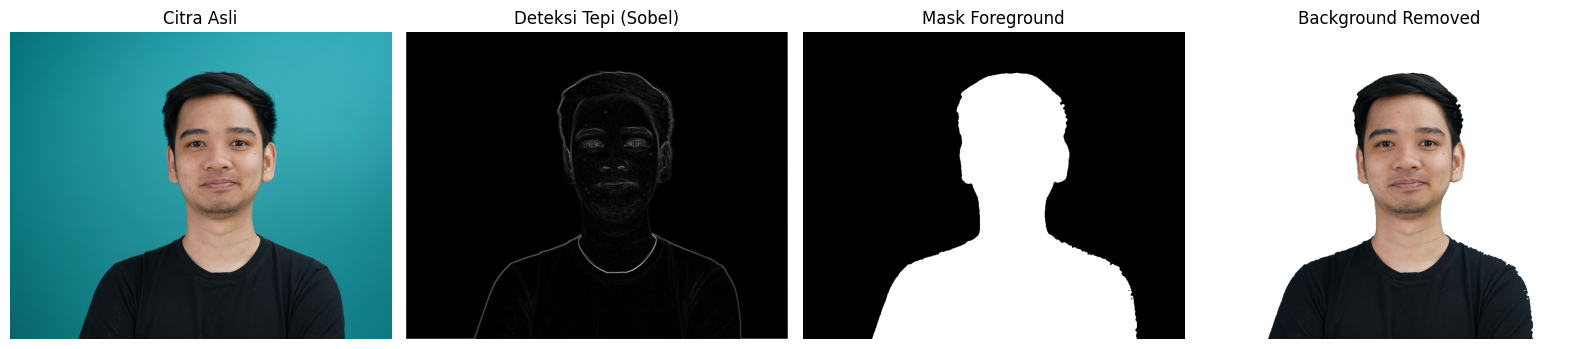

In [ ]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.title("Citra Asli")
plt.imshow(david)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("Deteksi Tepi (Sobel)")
plt.imshow(davidtepi, cmap="gray")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("Mask Foreground")
plt.imshow(mask_fg, cmap="gray")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("Background Removed")
plt.imshow(david_no_bg)
plt.axis('off')

plt.tight_layout()
plt.show()

### proses

Proses dimulai dari pembacaan citra asli david yang kemudian diubah menjadi citra grayscale untuk proses sharpening dan deteksi tepi menggunakan operator Sobel. Setelah itu, dilakukan deteksi background berwarna toska melalui fungsi detect_teal_background() dengan membandingkan nilai channel RGB, di mana area dengan dominasi warna hijau dan biru dianggap sebagai background. Hasil deteksi berupa mask boolean kemudian dikonversi menjadi citra biner dan diperhalus menggunakan filter median agar noise pada mask berkurang. Selanjutnya, dibuat mask foreground dan background yang lebih bersih sehingga objek utama dapat dipisahkan dengan lebih jelas. Pada tahap akhir, fungsi remove_background() digunakan untuk mengganti area background menjadi warna putih, sehingga diperoleh citra hasil dengan background yang telah dihilangkan dan objek utama tetap terlihat.

## **kesimpulan

perbaikan kualitas citra berguna untuk membuat gambar menjadi lebih jelas sehingga detail objek lebih mudah dilihat dan dianalisis. Proses seperti smoothing, sharpening, dan filtering dapat membantu mengurangi noise serta memperjelas detail pada gambar. Sedangkan deteksi tepi digunakan untuk menampilkan batas atau bentuk objek pada citra sehingga objek lebih mudah dikenali dan dipisahkan dari background. Dari hasil percobaan juga terlihat bahwa kombinasi perbaikan citra dan deteksi tepi membuat proses pengolahan gambar menjadi lebih baik dan membantu identifikasi objek dengan lebih jelas.